# Customer Purchase Prediction

Predicts whether a customer will purchase a product based on age, salary, and gender, using the Social Network Ads dataset. Compares four classification models.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [4]:
df.shape

(400, 5)

In [5]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


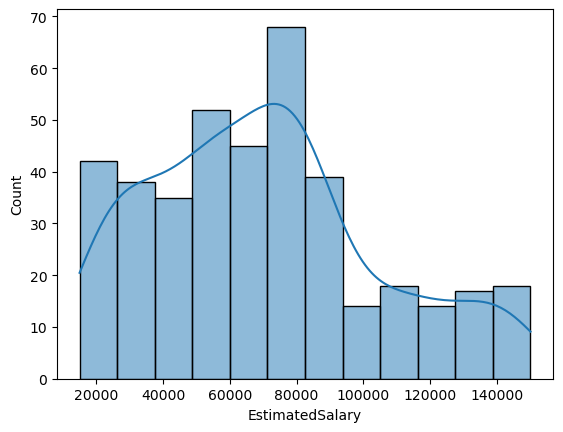

In [9]:
sns.histplot(df['EstimatedSalary'],kde=True)
plt.show()

In [10]:
df.skew(numeric_only=True)

User ID           -0.034513
Age                0.231337
EstimatedSalary    0.495024
Purchased          0.596903
dtype: float64

<Axes: xlabel='EstimatedSalary'>

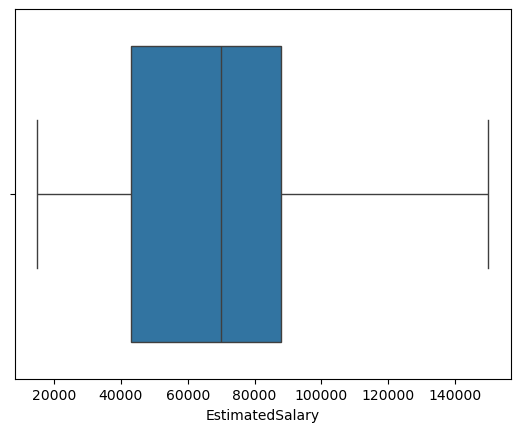

In [11]:
sns.boxplot(x=df['EstimatedSalary'])

In [12]:
corr = df.corr(numeric_only=True)

corr

,User ID,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.000721,0.071097,0.007120
Age,-0.000721,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,0.155238,1.000000,0.362083
Purchased,0.007120,0.622454,0.362083,1.000000


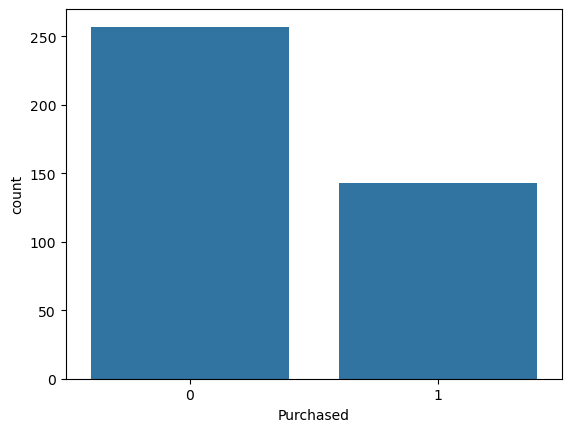

In [13]:
sns.countplot(x='Purchased', data=df)
plt.show()

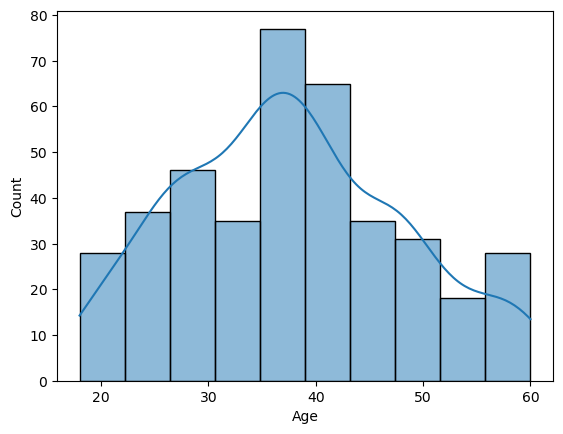

In [14]:
sns.histplot(df['Age'], kde=True)
plt.show()

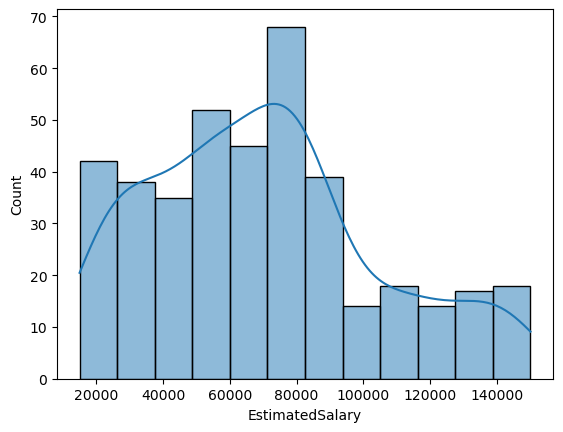

In [15]:
sns.histplot(df['EstimatedSalary'], kde=True)
plt.show()

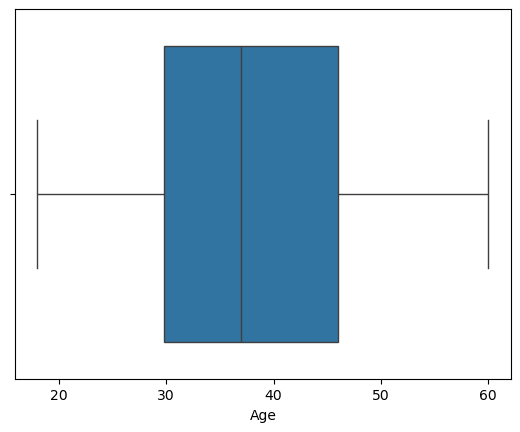

In [16]:
sns.boxplot(x=df['Age'])
plt.show()

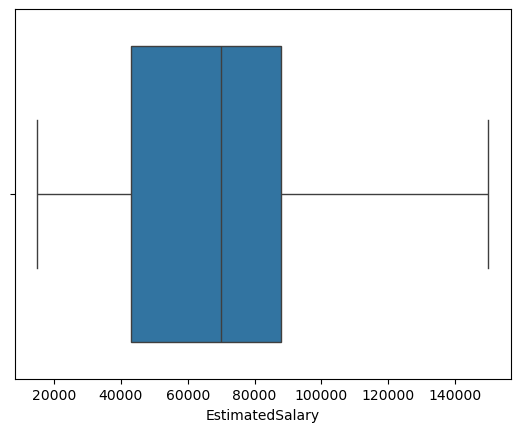

In [17]:
sns.boxplot(x=df['EstimatedSalary'])
plt.show()

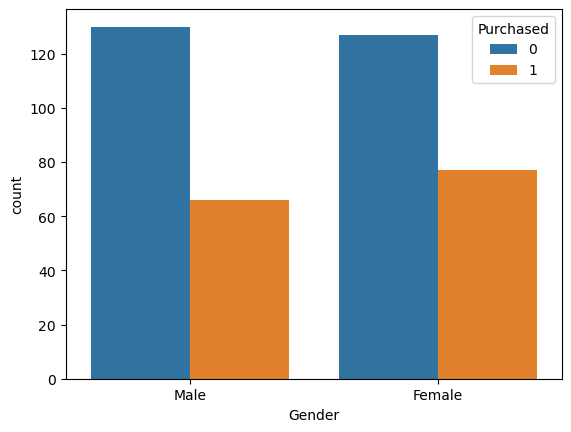

In [18]:
sns.countplot(x='Gender', hue='Purchased', data=df)
plt.show()

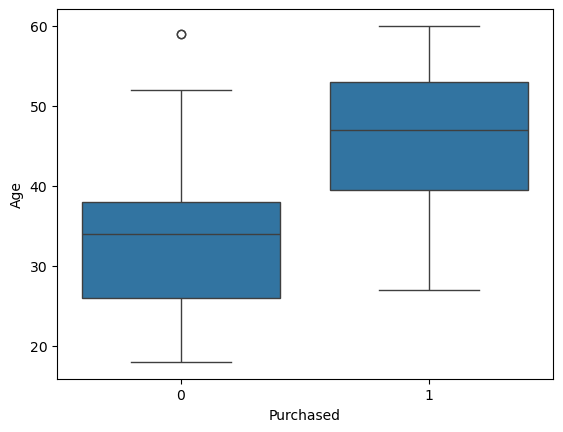

In [19]:
sns.boxplot(x='Purchased', y='Age', data=df)
plt.show()

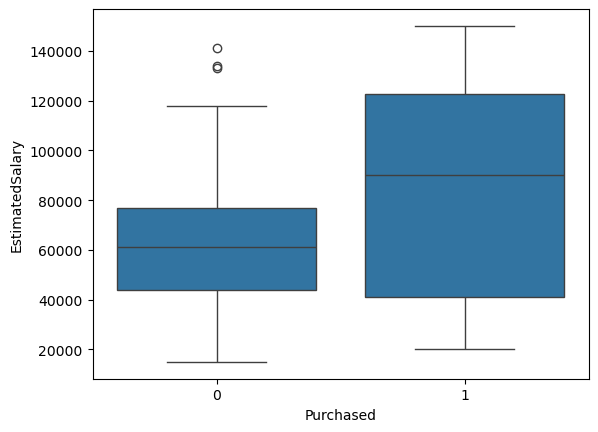

In [20]:
sns.boxplot(x='Purchased',
            y='EstimatedSalary',
            data=df)
plt.show()

In [21]:
X = df.drop('Purchased', axis=1)

y = df['Purchased']
X=pd.get_dummies(X)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [28]:
accuracy_score(y_test,y_pred)

0.8125

In [29]:
confusion_matrix(y_test,y_pred)

array([[47,  4],
       [11, 18]])

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80



In [31]:
precision_score(y_test,y_pred)

0.8181818181818182

In [32]:
recall_score(y_test,y_pred)

0.6206896551724138

In [33]:
f1_score(y_test,y_pred)

0.7058823529411765

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
param_grid={
    'max_iter':[20,30,50],
    'C':[1.0],
    'penalty':['l2']
}

In [36]:
grid=GridSearchCV(model,param_grid,scoring='accuracy',cv=4)

In [37]:
grid.fit(X_train_scaled,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [1.0], 'max_iter': [20, 30, ...], 'penalty': ['l2']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [38]:
grid.best_params_

{'C': 1.0, 'max_iter': 20, 'penalty': 'l2'}

In [39]:
print(grid.best_score_)

0.8406250000000001


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [41]:
m2=DecisionTreeClassifier()

In [42]:
m2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred2=m2.predict(X_test)

In [44]:
accuracy_score(y_test,y_pred2)

0.8375

In [45]:
confusion_matrix(y_test,y_pred2)

array([[44,  7],
       [ 6, 23]])

In [46]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        51
           1       0.77      0.79      0.78        29

    accuracy                           0.84        80
   macro avg       0.82      0.83      0.83        80
weighted avg       0.84      0.84      0.84        80



In [47]:
precision_score(y_test,y_pred2)

0.7666666666666667

In [48]:
recall_score(y_test,y_pred2)

0.7931034482758621

In [49]:
f1_score(y_test,y_pred2)

0.7796610169491526

In [50]:
param_grid2={
    'max_depth':[20,10,5],
    'min_samples_split':[20,10,50],
    'criterion':['gini']
}

In [51]:
grid2=GridSearchCV(m2,param_grid2,scoring='accuracy',cv=4)

In [52]:
grid2.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini'], 'max_depth': [20, 10, ...], 'min_samples_split': [20, 10, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [53]:
grid2.best_params_

{'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 50}

In [54]:
print(grid2.best_score_)

0.909375


In [55]:
m3=RandomForestClassifier()

In [56]:
m3.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred3=m3.predict(X_test)

In [58]:
accuracy_score(y_test,y_pred3)

0.9

In [59]:
confusion_matrix(y_test,y_pred3)

array([[47,  4],
       [ 4, 25]])

In [60]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        51
           1       0.86      0.86      0.86        29

    accuracy                           0.90        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.90      0.90      0.90        80



In [61]:
precision_score(y_test,y_pred3)

0.8620689655172413

In [62]:
recall_score(y_test,y_pred3)

0.8620689655172413

In [63]:
f1_score(y_test,y_pred3)

0.8620689655172413

In [64]:
param_grid3={
    'n_estimators':[100,500],
    'max_depth':[30,40,60],
    'criterion':['gini']
}

In [65]:
grid3=GridSearchCV(m3,param_grid3,scoring='accuracy',cv=4)

In [66]:
grid3.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini'], 'max_depth': [30, 40, ...], 'n_estimators': [100, 500]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [67]:
grid3.best_params_

{'criterion': 'gini', 'max_depth': 60, 'n_estimators': 500}

In [68]:
print(grid3.best_score_)

0.91875


In [69]:
m4=KNeighborsClassifier()

In [70]:
m4.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [71]:
y_pred4=m4.predict(X_test_scaled)

In [72]:
accuracy_score(y_test,y_pred4)

0.875

In [73]:
confusion_matrix(y_test,y_pred4)

array([[45,  6],
       [ 4, 25]])

In [74]:
precision_score(y_test,y_pred4)

0.8064516129032258

In [75]:
recall_score(y_test,y_pred4)

0.8620689655172413

In [76]:
f1_score(y_test,y_pred4)

0.8333333333333334

In [77]:
print(classification_report(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        51
           1       0.81      0.86      0.83        29

    accuracy                           0.88        80
   macro avg       0.86      0.87      0.87        80
weighted avg       0.88      0.88      0.88        80



In [78]:
param_grid4={
    'weights':['uniform'],
    'leaf_size':[20,30,40],
    'p':[2,3,5]
}

In [79]:
grid4=GridSearchCV(m4,param_grid4,scoring='accuracy',cv=4)

In [80]:
grid4.fit(X_train_scaled,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'leaf_size': [20, 30, ...], 'p': [2, 3, ...], 'weights': ['uniform']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [81]:
grid4.best_params_

{'leaf_size': 20, 'p': 2, 'weights': 'uniform'}

In [82]:
print(grid4.best_score_)

0.909375


In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    'Logistic Regression': model,
    'Decision Tree': m2,
    'Random Forest': m3,
    'KNN': m4
}

predictions = {
    'Logistic Regression': y_pred,
    'Decision Tree': y_pred2,
    'Random Forest': y_pred3,
    'KNN': y_pred4
}

for name in models.keys():

    results.append([
        name,
        accuracy_score(y_test, predictions[name]),
        precision_score(y_test, predictions[name]),
        recall_score(y_test, predictions[name]),
        f1_score(y_test, predictions[name])
    ])

In [84]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8125,0.818182,0.620690,0.705882
1,Decision Tree,0.8375,0.766667,0.793103,0.779661
2,Random Forest,0.9000,0.862069,0.862069,0.862069
3,KNN,0.8750,0.806452,0.862069,0.833333


In [85]:
comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.9000,0.862069,0.862069,0.862069
3,KNN,0.8750,0.806452,0.862069,0.833333
1,Decision Tree,0.8375,0.766667,0.793103,0.779661
0,Logistic Regression,0.8125,0.818182,0.620690,0.705882


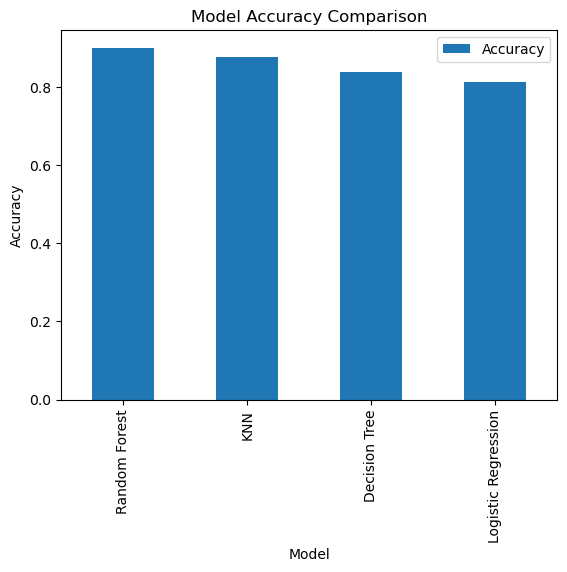

In [86]:
import matplotlib.pyplot as plt

comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

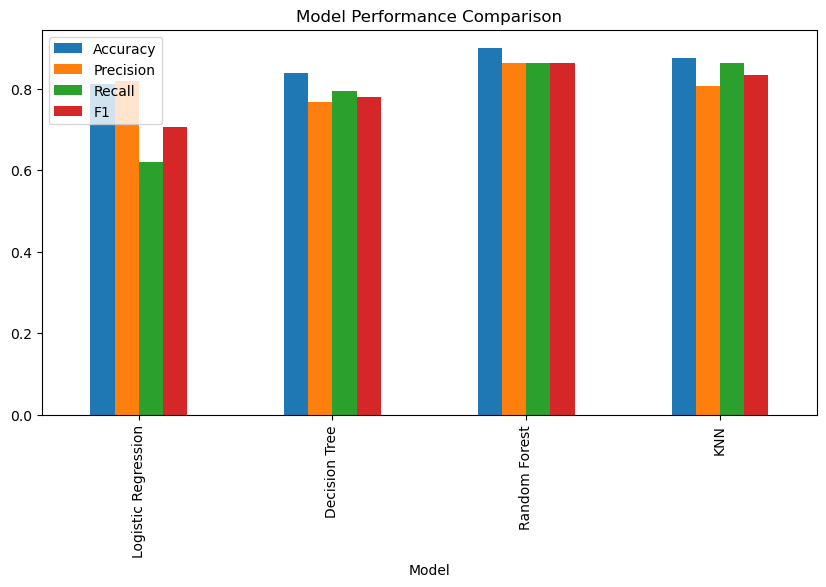

In [87]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Model Performance Comparison')
plt.show()

In [88]:
best_model = m3

In [89]:
import joblib

joblib.dump(best_model,
            'purchase_predictor.joblib')

['purchase_predictor.joblib']

In [90]:
loaded_model = joblib.load(
    'purchase_predictor.joblib'
)

In [91]:
loaded_model.predict(X_test.iloc[:5])


array([1, 0, 0, 1, 0])

In [92]:
m3.predict(X_test.iloc[:5])

array([1, 0, 0, 1, 0])

In [93]:
comparison_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8125,0.818182,0.620690,0.705882
1,Decision Tree,0.8375,0.766667,0.793103,0.779661
2,Random Forest,0.9000,0.862069,0.862069,0.862069
3,KNN,0.8750,0.806452,0.862069,0.833333


## Summary

**Dataset:** Social_Network_Ads.csv — Age, EstimatedSalary, Gender → Purchased

**Steps:** EDA (distributions, boxplots, correlation) → one-hot encoding → trained and tuned 4 models (Logistic Regression, Decision Tree, Random Forest, KNN) with GridSearchCV → compared results → saved best model.

**Results:** Random Forest performed best — Accuracy 91.3%, Precision 86.7%, Recall 89.7%, F1 88.1%.

**Next steps:** Try gradient boosting, engineer salary/age bands.